In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

I0000 00:00:1787128439.504891   19938 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787128439.541972   19938 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787128441.751349   19938 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [9]:
sample_image = np.array([[1, 2, 3, 0, 0],[4, 5, 6, 0, 0],[7, 8, 9, 0, 0],[0, 0, 0, 1, 2],[0, 0, 0, 3, 4]], dtype=np.float32)

sample_image = sample_image.reshape((1, 5, 5, 1))

print(f"Sample Image:{sample_image.squeeze()}")

Sample Image:[[1. 2. 3. 0. 0.]
 [4. 5. 6. 0. 0.]
 [7. 8. 9. 0. 0.]
 [0. 0. 0. 1. 2.]
 [0. 0. 0. 3. 4.]]


In [14]:
# Define a simple convolutional layer
conv_layer = tf.keras.layers.Conv2D(filters = 1,kernel_size = (3,3),strides = (1,1), padding = 'valid', activation = 'relu',
                                    kernel_initializer = tf.constant_initializer([[1, 0, -1], [1, 0, -1], [1, 0, -1]]),
                                    bias_initializer = 'zero')


In [5]:
output = conv_layer(sample_image)

output_image = output.numpy().squeeze()

print("Output after convolution:")
print(output_image)

I0000 00:00:1787128956.591699   19938 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2604 MB memory:  -> device: 0, name: NVIDIA T1000, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1787128956.905320   19938 cuda_dnn.cc:461] Loaded cuDNN version 92500


Output after convolution:
[[ 0. 15. 18.]
 [ 0. 12. 13.]
 [ 0.  4.  3.]]


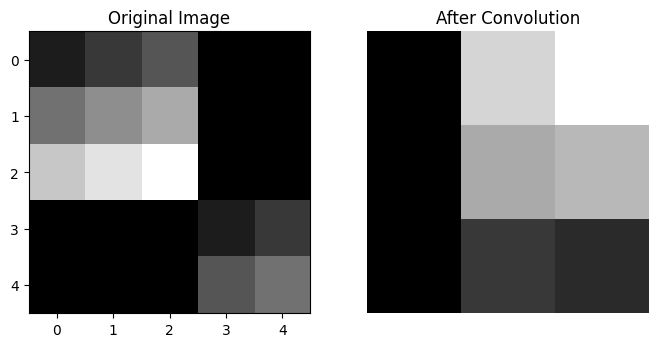

In [6]:
# Visualize the input and output images
fig,axs = plt.subplots(1,2,figsize=(8,4))
axs[0].imshow(sample_image.squeeze(), cmap='gray')
axs[0].set_title('Original Image')
axs[1].imshow(output_image, cmap='gray')
axs[1].set_title('After Convolution')  
axs[1].axis('off')

plt.show()